<a href="https://colab.research.google.com/github/Damyoungtechnologies/airguard/blob/main/airguard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Loading the Libraries

In [4]:
 !git clone https://github.com/Damyoungtechnologies/airguard.git

Cloning into 'airguard'...
remote: Enumerating objects: 35, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (30/30), done.
remote: Total 35 (delta 2), reused 35 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (35/35), 46.05 KiB | 5.12 MiB/s, done.
Resolving deltas: 100% (2/2), done.


In [5]:
%cd /content/airguard

/content/airguard


In [6]:
%cd /content/airguard
!ls
!git status

/content/airguard
backend  frontend
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [7]:
!pwd

/content/airguard


In [8]:
!ls

backend  frontend


In [9]:
%cd /content/airguard
!mkdir ml

/content/airguard


In [10]:
!mkdir -p ml/models
!mkdir -p ml/notebooks
!mkdir -p ml/data

In [ ]:
import joblib

joblib.dump(model, "/content/airguard/ml/models/drug_model.pkl")

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import root_mean_squared_error, r2_score

# 2. Loading the Data
Note that the data, `lagos_emissions_data` used in this project was simulated.

In [ ]:
df = pd.read_csv("lagos_emissions_dataset.csv")

In [ ]:
df.head()

,ID,Region,Latitude,Longitude,Year,Month,Day_of_Week,Hour,Emissions
0,1,Mushin,6.54773,3.35327,2018.0,2.0,1.0,4.0,598.28
1,2,Alimosho,6.62012,3.26714,2016.0,12.0,6.0,12.0,756.42
2,3,Badagry,6.40908,2.88641,2019.0,3.0,5.0,0.0,527.17
3,4,Epe,6.57687,3.98305,2021.0,11.0,0.0,0.0,553.90
4,5,Ajeromi-Ifelodun,6.45783,3.31263,2023.0,3.0,1.0,22.0,1135.71


## 3. Data Exploration and Visualization

In [ ]:
# Display basic info and check for missing values
df.info()
print("\nMissing values per column:\n", df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 726291 entries, 0 to 726290
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   ID           726291 non-null  int64  
 1   Region       726291 non-null  object 
 2   Latitude     726290 non-null  float64
 3   Longitude    726290 non-null  float64
 4   Year         726290 non-null  float64
 5   Month        726290 non-null  float64
 6   Day_of_Week  726290 non-null  float64
 7   Hour         726290 non-null  float64
 8   Emissions    726290 non-null  float64
dtypes: float64(7), int64(1), object(1)
memory usage: 49.9+ MB

Missing values per column:
 ID             0
Region         0
Latitude       1
Longitude      1
Year           1
Month          1
Day_of_Week    1
Hour           1
Emissions      1
dtype: int64


In [ ]:
# Convert 'Year', 'Month', 'Hour', 'Day_of_Week' to integer, dropping rows with NaN in these columns
df_cleaned = df.dropna(subset=['Year', 'Month', 'Hour', 'Day_of_Week']).copy()
df_cleaned['Year'] = df_cleaned['Year'].astype(int)
df_cleaned['Month'] = df_cleaned['Month'].astype(int)
df_cleaned['Hour'] = df_cleaned['Hour'].astype(int)
df_cleaned['Day_of_Week'] = df_cleaned['Day_of_Week'].astype(int)

print("\nDataFrame after cleaning 'Year', 'Month', 'Hour', 'Day_of_Week' columns:")
df_cleaned.info()


DataFrame after cleaning 'Year', 'Month', 'Hour', 'Day_of_Week' columns:
<class 'pandas.core.frame.DataFrame'>
Index: 726290 entries, 0 to 726289
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   ID           726290 non-null  int64  
 1   Region       726290 non-null  object 
 2   Latitude     726290 non-null  float64
 3   Longitude    726290 non-null  float64
 4   Year         726290 non-null  int64  
 5   Month        726290 non-null  int64  
 6   Day_of_Week  726290 non-null  int64  
 7   Hour         726290 non-null  int64  
 8   Emissions    726290 non-null  float64
dtypes: float64(3), int64(5), object(1)
memory usage: 55.4+ MB


### 3.1. Emissions Distribution

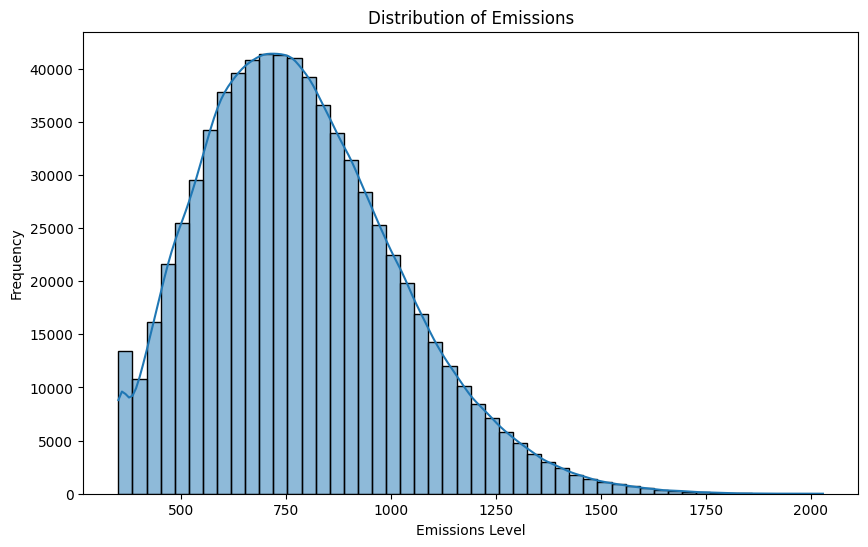

In [ ]:
# Histogram of Emissions
plt.figure(figsize=(10, 6))
sns.histplot(df_cleaned['Emissions'], kde=True, bins=50)
plt.title('Distribution of Emissions')
plt.xlabel('Emissions Level')
plt.ylabel('Frequency')
plt.show()

### 3.2. Region vs. Emissions

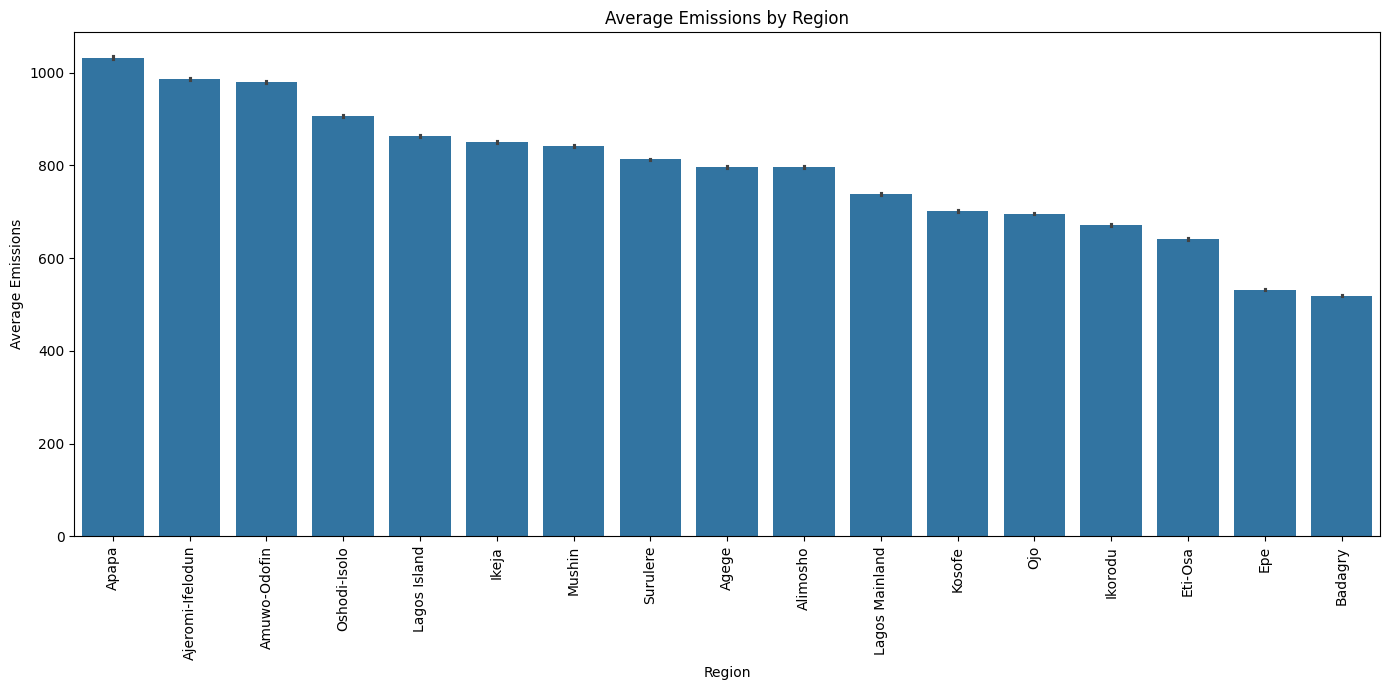

In [ ]:
# Bar chart of average Emissions by Region
plt.figure(figsize=(14, 7))
sns.barplot(x='Region', y='Emissions', data=df_cleaned, estimator=np.mean, order=df_cleaned.groupby('Region')['Emissions'].mean().sort_values(ascending=False).index)
plt.title('Average Emissions by Region')
plt.xlabel('Region')
plt.ylabel('Average Emissions')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

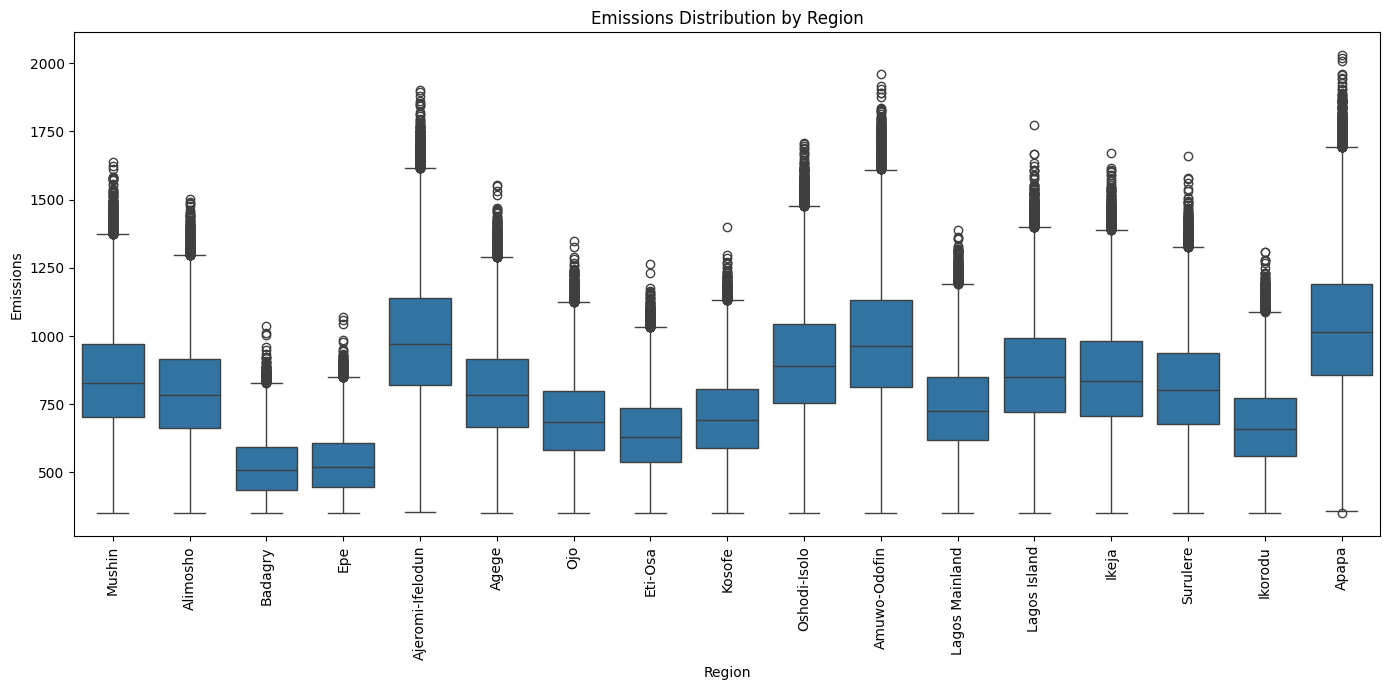

In [ ]:
# Box plot of Emissions by Region to show distribution
plt.figure(figsize=(14, 7))
sns.boxplot(x='Region', y='Emissions', data=df_cleaned)
plt.title('Emissions Distribution by Region')
plt.xlabel('Region')
plt.ylabel('Emissions')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### 3.3. Emissions Trends: Year, Month, and Hour by Region

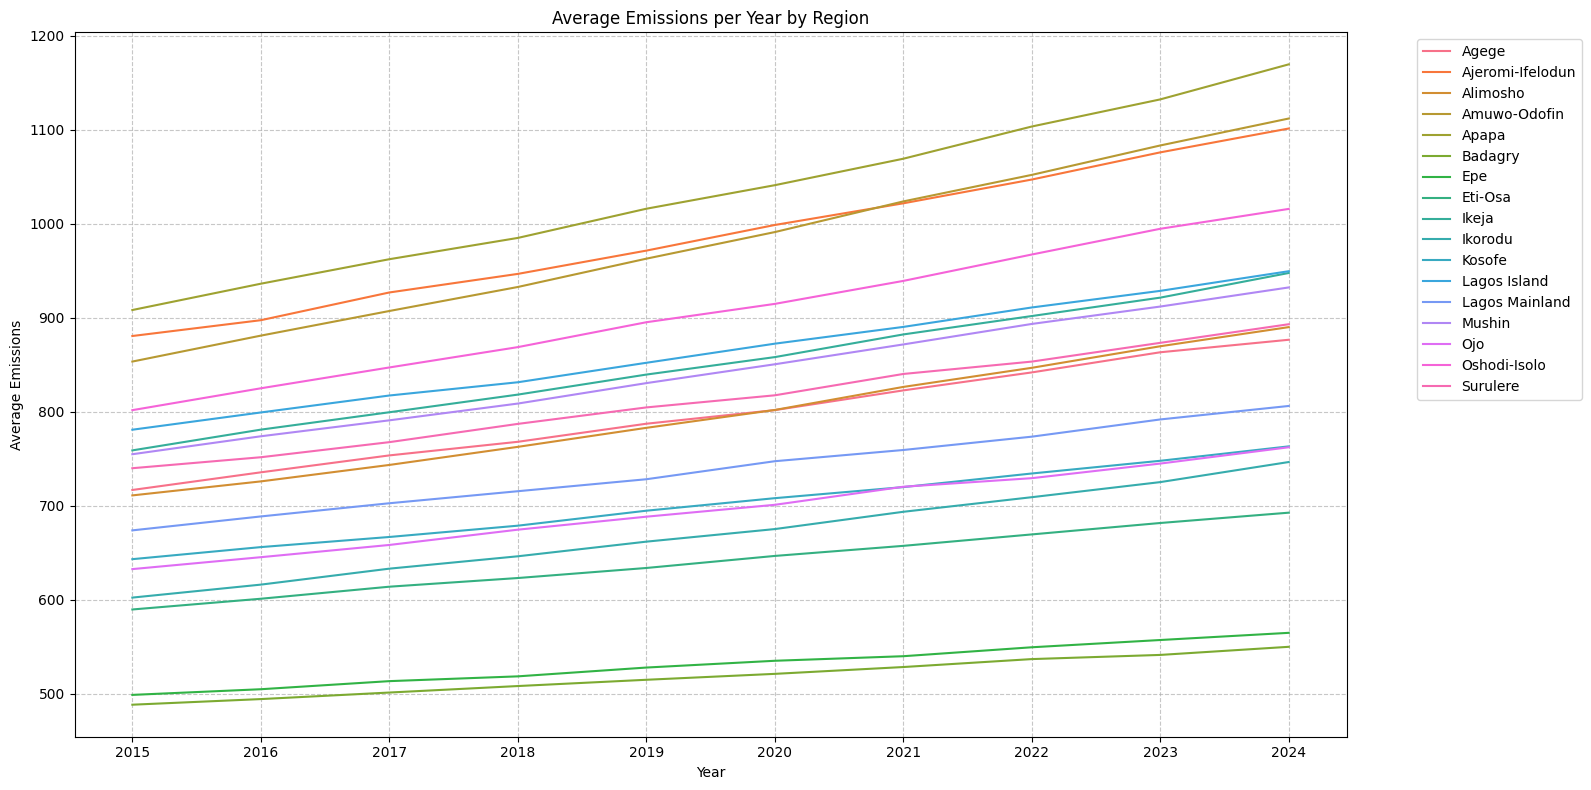

In [ ]:
# Line plots for Emissions per Year for each Region
plt.figure(figsize=(16, 8))
sns.lineplot(x='Year', y='Emissions', hue='Region', data=df_cleaned.groupby(['Region', 'Year'])['Emissions'].mean().reset_index())
plt.title('Average Emissions per Year by Region')
plt.xlabel('Year')
plt.ylabel('Average Emissions')
plt.xticks(df_cleaned['Year'].unique())
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

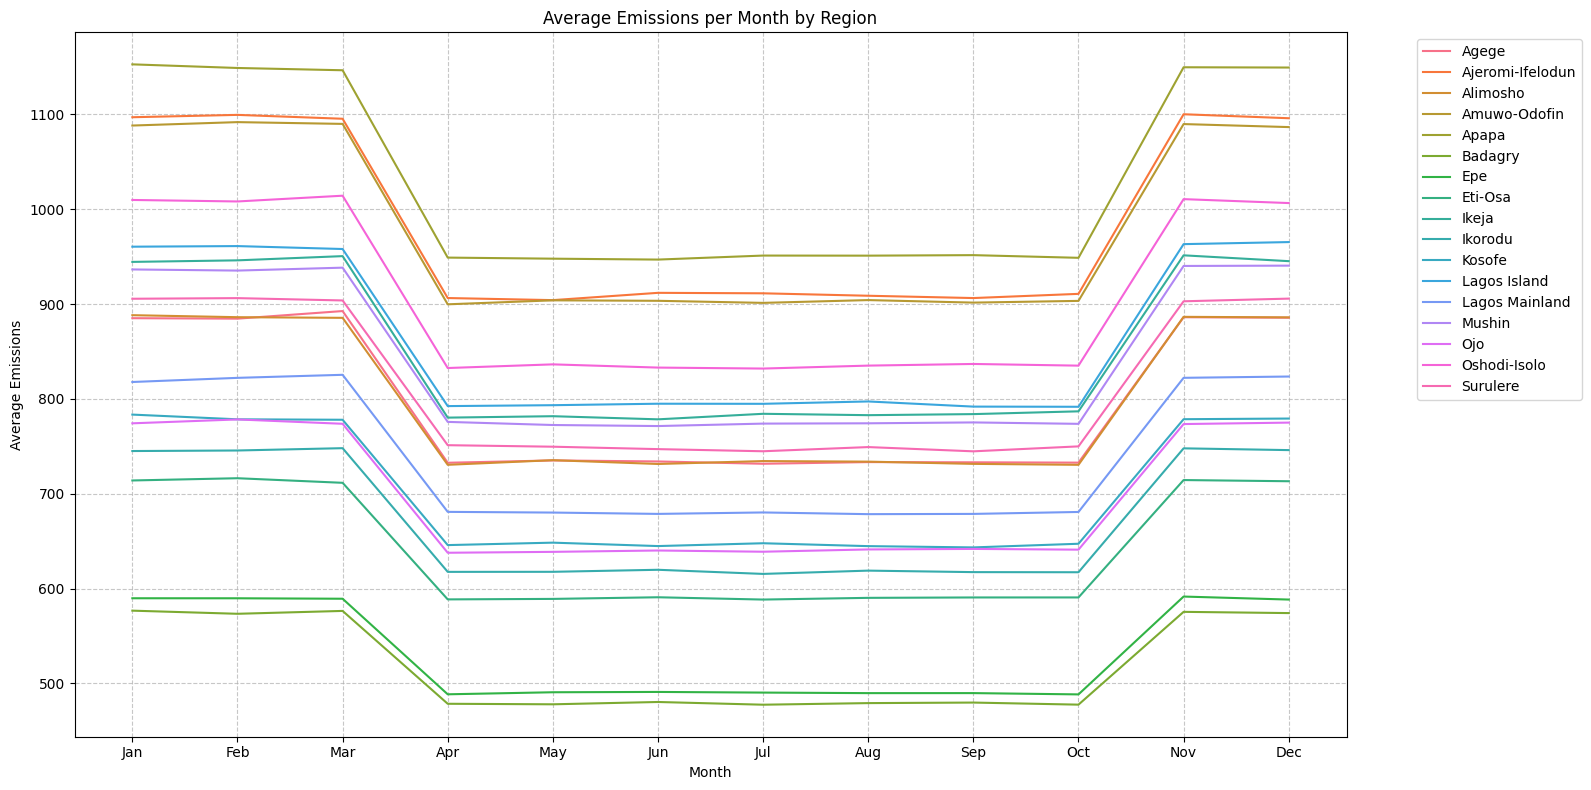

In [ ]:
# Line plots for Emissions per Month for each Region
plt.figure(figsize=(16, 8))
sns.lineplot(x='Month', y='Emissions', hue='Region', data=df_cleaned.groupby(['Region', 'Month'])['Emissions'].mean().reset_index())
plt.title('Average Emissions per Month by Region')
plt.xlabel('Month')
plt.ylabel('Average Emissions')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

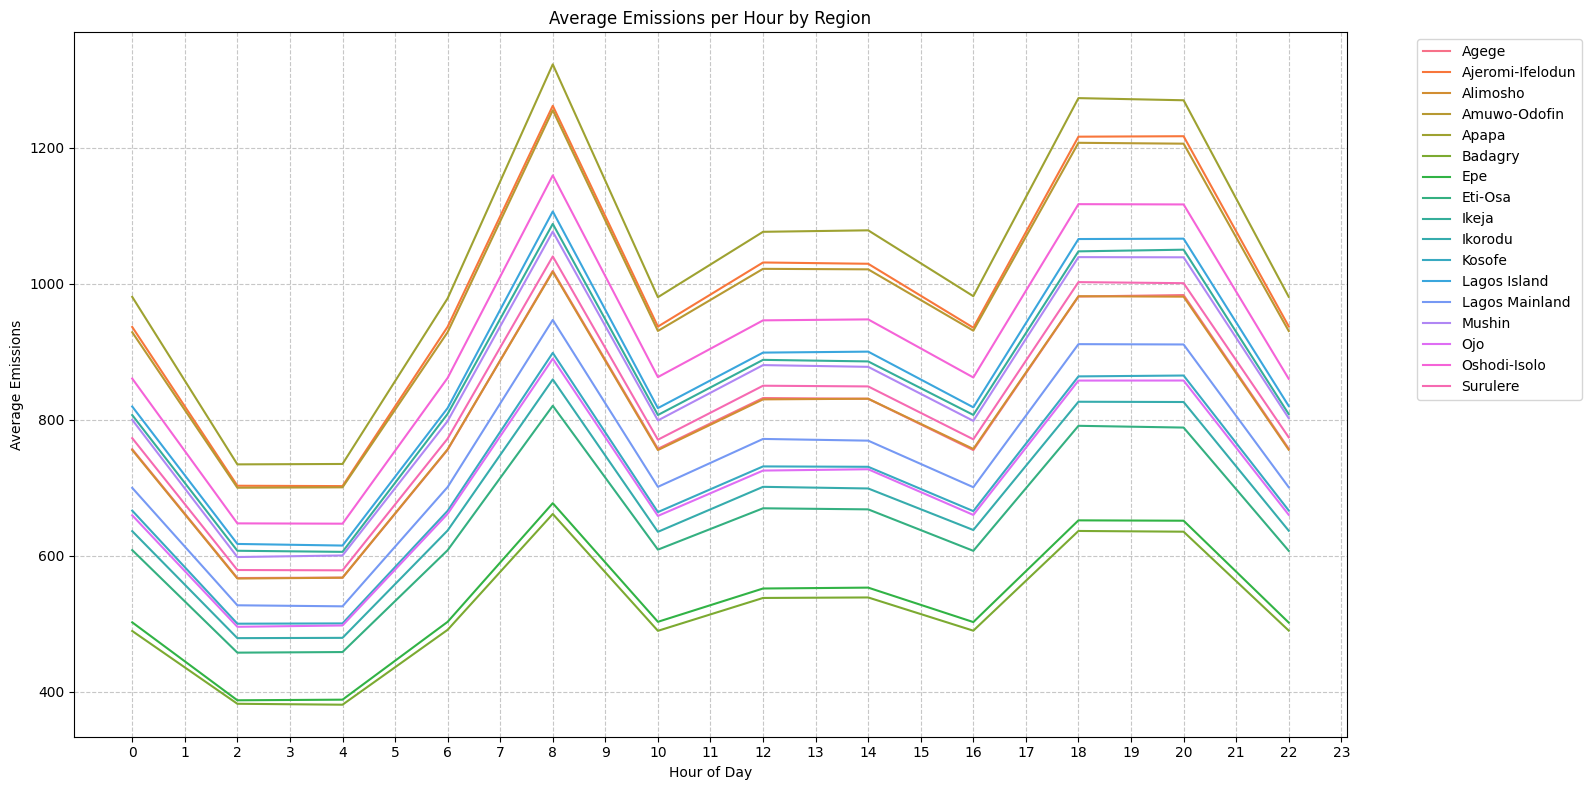

In [ ]:
# Line plots for Emissions per Hour for each Region
plt.figure(figsize=(16, 8))
sns.lineplot(x='Hour', y='Emissions', hue='Region', data=df_cleaned.groupby(['Region', 'Hour'])['Emissions'].mean().reset_index())
plt.title('Average Emissions per Hour by Region')
plt.xlabel('Hour of Day')
plt.ylabel('Average Emissions')
plt.xticks(range(0, 24))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

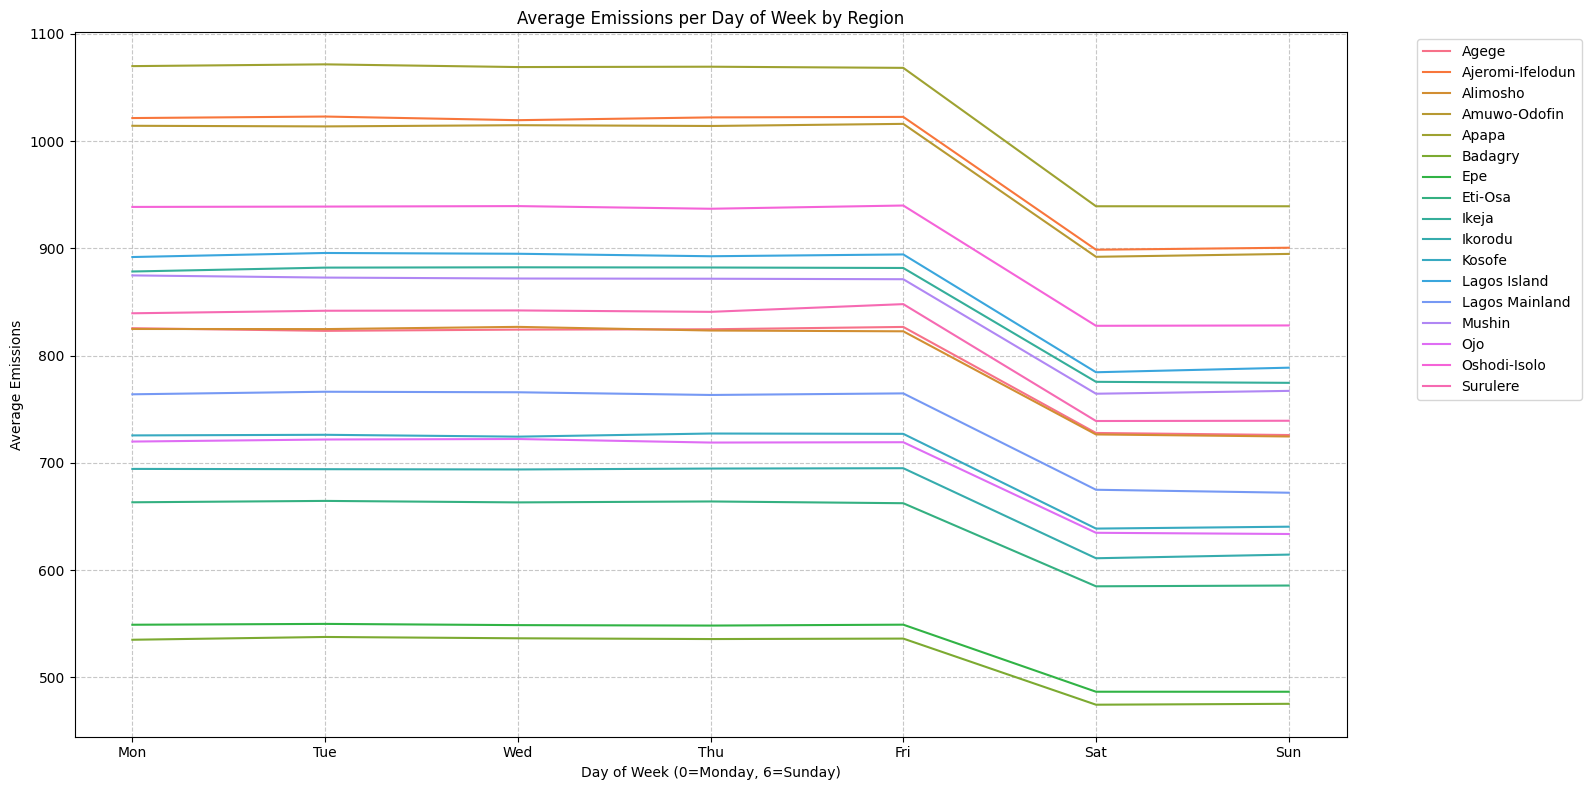

In [ ]:
# Day of Week vs. Emissions for each Region
plt.figure(figsize=(16, 8))
sns.lineplot(x='Day_of_Week', y='Emissions', hue='Region', data=df_cleaned.groupby(['Region', 'Day_of_Week'])['Emissions'].mean().reset_index())
plt.title('Average Emissions per Day of Week by Region')
plt.xlabel('Day of Week (0=Monday, 6=Sunday)')
plt.ylabel('Average Emissions')
plt.xticks(range(0, 7), ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

From the visuals, we are observing a somewhat linear trend for Average Emissions per Year by Region.

When observing the emissions per month, we see a different trend. The emission levels drop from march to april and remain at a fixed amount until october, where it rises again. This suggests that most of the significant changes happen from march to april and octoober to november.

## 4. Data Preprocessing for Modeling

### 4.1 Feature Engineering: Cyclical Features for Time-based Data

In [ ]:
# Create cyclical features for 'Month', 'Day_of_Week', and 'Hour'
df_processed = df_cleaned.copy()

df_processed['Month_sin'] = np.sin(2 * np.pi * df_processed['Month'] / 12)
df_processed['Month_cos'] = np.cos(2 * np.pi * df_processed['Month'] / 12)
df_processed['Day_of_Week_sin'] = np.sin(2 * np.pi * df_processed['Day_of_Week'] / 7)
df_processed['Day_of_Week_cos'] = np.cos(2 * np.pi * df_processed['Day_of_Week'] / 7)
df_processed['Hour_sin'] = np.sin(2 * np.pi * df_processed['Hour'] / 24)
df_processed['Hour_cos'] = np.cos(2 * np.pi * df_processed['Hour'] / 24)

# Drop original time-based columns
df_processed = df_processed.drop(columns=['Month', 'Day_of_Week', 'Hour'])

print("DataFrame after adding cyclical features:")
display(df_processed.head())

DataFrame after adding cyclical features:


,ID,Region,Latitude,Longitude,Year,Emissions,Month_sin,Month_cos,Day_of_Week_sin,Day_of_Week_cos,Hour_sin,Hour_cos
0,1,Mushin,6.54773,3.35327,2018,598.28,8.660254e-01,5.000000e-01,0.781831,0.623490,8.660254e-01,0.500000
1,2,Alimosho,6.62012,3.26714,2016,756.42,-2.449294e-16,1.000000e+00,-0.781831,0.623490,1.224647e-16,-1.000000
2,3,Badagry,6.40908,2.88641,2019,527.17,1.000000e+00,6.123234e-17,-0.974928,-0.222521,0.000000e+00,1.000000
3,4,Epe,6.57687,3.98305,2021,553.90,-5.000000e-01,8.660254e-01,0.000000,1.000000,0.000000e+00,1.000000
4,5,Ajeromi-Ifelodun,6.45783,3.31263,2023,1135.71,1.000000e+00,6.123234e-17,0.781831,0.623490,-5.000000e-01,0.866025


### 4.2 Handling Categorical Variables: One-Hot Encoding for 'Region'

In [ ]:
# One-hot encode the 'Region' column
df_processed = pd.get_dummies(df_processed, columns=['Region'], drop_first=True)

print("DataFrame after one-hot encoding 'Region':")
display(df_processed.head())

DataFrame after one-hot encoding 'Region':


,ID,Latitude,Longitude,Year,Emissions,Month_sin,Month_cos,Day_of_Week_sin,Day_of_Week_cos,Hour_sin,...,Region_Eti-Osa,Region_Ikeja,Region_Ikorodu,Region_Kosofe,Region_Lagos Island,Region_Lagos Mainland,Region_Mushin,Region_Ojo,Region_Oshodi-Isolo,Region_Surulere
0,1,6.54773,3.35327,2018,598.28,8.660254e-01,5.000000e-01,0.781831,0.623490,8.660254e-01,...,False,False,False,False,False,False,True,False,False,False
1,2,6.62012,3.26714,2016,756.42,-2.449294e-16,1.000000e+00,-0.781831,0.623490,1.224647e-16,...,False,False,False,False,False,False,False,False,False,False
2,3,6.40908,2.88641,2019,527.17,1.000000e+00,6.123234e-17,-0.974928,-0.222521,0.000000e+00,...,False,False,False,False,False,False,False,False,False,False
3,4,6.57687,3.98305,2021,553.90,-5.000000e-01,8.660254e-01,0.000000,1.000000,0.000000e+00,...,False,False,False,False,False,False,False,False,False,False
4,5,6.45783,3.31263,2023,1135.71,1.000000e+00,6.123234e-17,0.781831,0.623490,-5.000000e-01,...,False,False,False,False,False,False,False,False,False,False


### 4.3 Define Features (X) and Target (y)

In [ ]:
# Define features (X) and target (y)
X = df_processed.drop(columns=['ID', 'Emissions'])
y = df_processed['Emissions']

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

Features (X) shape: (726290, 25)
Target (y) shape: (726290,)


### 4.4 Splitting the Data into Training and Testing Sets

In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (581032, 25)
X_test shape: (145258, 25)
y_train shape: (581032,)
y_test shape: (145258,)


### 4.5 Scaling Numerical Features

In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# List of numerical columns to scale (excluding one-hot encoded and cyclical features which are already scaled implicitly or suitable)
# In this case, Latitude, Longitude, and Year are the primary numerical features.
numerical_cols = ['Latitude', 'Longitude', 'Year']

# Scale the numerical features
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("X_train after scaling numerical features:")
display(X_train.head())
print("X_test after scaling numerical features:")
display(X_test.head())

X_train after scaling numerical features:


,Latitude,Longitude,Year,Month_sin,Month_cos,Day_of_Week_sin,Day_of_Week_cos,Hour_sin,Hour_cos,Region_Ajeromi-Ifelodun,...,Region_Eti-Osa,Region_Ikeja,Region_Ikorodu,Region_Kosofe,Region_Lagos Island,Region_Lagos Mainland,Region_Mushin,Region_Ojo,Region_Oshodi-Isolo,Region_Surulere
133721,0.870113,0.128948,-0.522324,1.000000,6.123234e-17,0.781831,0.623490,0.866025,-5.000000e-01,False,...,False,False,False,True,False,False,False,False,False,False
50486,1.389282,-0.427057,0.173712,0.500000,8.660254e-01,-0.974928,-0.222521,-0.866025,-5.000000e-01,False,...,False,False,False,False,False,False,False,False,False,False
597554,-1.432702,-2.426528,-0.870342,0.500000,8.660254e-01,-0.433884,-0.900969,1.000000,6.123234e-17,False,...,False,False,False,False,False,False,False,False,False,False
204160,-0.679051,-0.216936,-0.522324,0.866025,5.000000e-01,0.974928,-0.222521,0.866025,-5.000000e-01,True,...,False,False,False,False,False,False,False,False,False,False
127692,0.408198,-0.234270,0.869748,-0.500000,-8.660254e-01,-0.974928,-0.222521,0.866025,-5.000000e-01,False,...,False,False,False,False,False,False,False,False,True,False


X_test after scaling numerical features:


,Latitude,Longitude,Year,Month_sin,Month_cos,Day_of_Week_sin,Day_of_Week_cos,Hour_sin,Hour_cos,Region_Ajeromi-Ifelodun,...,Region_Eti-Osa,Region_Ikeja,Region_Ikorodu,Region_Kosofe,Region_Lagos Island,Region_Lagos Mainland,Region_Mushin,Region_Ojo,Region_Oshodi-Isolo,Region_Surulere
439463,0.883635,0.160907,-1.218360,-5.000000e-01,0.866025,0.781831,0.623490,-8.660254e-01,0.500000,False,...,False,False,False,True,False,False,False,False,False,False
444045,0.909817,0.006234,1.217765,-5.000000e-01,-0.866025,-0.433884,-0.900969,5.000000e-01,-0.866025,False,...,False,True,False,False,False,False,False,False,False,False
569858,1.346989,-0.128988,0.869748,5.000000e-01,0.866025,-0.974928,-0.222521,8.660254e-01,-0.500000,False,...,False,False,False,False,False,False,False,False,False,False
252210,-0.261874,0.004116,-0.522324,-2.449294e-16,1.000000,-0.433884,-0.900969,-8.660254e-01,0.500000,False,...,False,False,False,False,False,False,False,False,False,True
283309,0.186087,-0.194285,0.173712,5.000000e-01,-0.866025,0.000000,1.000000,1.224647e-16,-1.000000,False,...,False,False,False,False,False,False,False,False,True,False


## 5. Model Training and Evaluation

### 5.1 XGBoost Regressor

In [ ]:
# Initialize and train the XGBoost Regressor
xgb_model = XGBRegressor(random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)

# Make predictions
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate the model
rmse_xgb = root_mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost Regressor RMSE: {rmse_xgb:.2f}")
print(f"XGBoost Regressor R2 Score: {r2_xgb:.2f}")

XGBoost Regressor RMSE: 65.48
XGBoost Regressor R2 Score: 0.92


### 5.2 Random Forest Regressor

In [ ]:
# Initialize and train the Random Forest Regressor
rf_model = RandomForestRegressor(random_state=42, n_jobs=-1, n_estimators=100)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
rmse_rf = root_mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest Regressor RMSE: {rmse_rf:.2f}")
print(f"Random Forest Regressor R2 Score: {r2_rf:.2f}")

Random Forest Regressor RMSE: 68.92
Random Forest Regressor R2 Score: 0.91


### 5.3 Ridge Regressor

In [ ]:
# Initialize and train the Ridge Regressor
ridge_model = Ridge(random_state=42)
ridge_model.fit(X_train, y_train)

# Make predictions
y_pred_ridge = ridge_model.predict(X_test)

# Evaluate the model
rmse_ridge = root_mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print(f"Ridge Regressor RMSE: {rmse_ridge:.2f}")
print(f"Ridge Regressor R2 Score: {r2_ridge:.2f}")

Ridge Regressor RMSE: 144.64
Ridge Regressor R2 Score: 0.62


### 5.4 Model Comparison

In [ ]:
# Create a DataFrame to compare model performance
results = pd.DataFrame({
    'Model': ['XGBoost Regressor', 'Random Forest Regressor', 'Ridge Regressor'],
    'RMSE': [rmse_xgb, rmse_rf, rmse_ridge],
    'R2 Score': [r2_xgb, r2_rf, r2_ridge]
})

print("\nModel Performance Comparison:")
display(results.sort_values(by='R2 Score', ascending=False))


Model Performance Comparison:


,Model,RMSE,R2 Score
0,XGBoost Regressor,65.476967,0.922868
1,Random Forest Regressor,68.923282,0.914534
2,Ridge Regressor,144.641259,0.623605


## 6. Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from scipy.stats import uniform, randint

### 6.1 XGBoost Regressor Tuning

In [ ]:
# Define the parameter distribution for RandomizedSearchCV
xgb_param_dist = {
    'n_estimators': randint(100, 500),
    'learning_rate': uniform(0.01, 0.2),
    'max_depth': randint(3, 10),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4)
}

# Initialize RandomizedSearchCV for XGBoost
# n_iter controls the number of parameter settings that are sampled.
# cv is the number of cross-validation folds.
# n_jobs=-1 uses all available CPU cores. For GPU, 'tree_method': 'gpu_hist' needs to be set in the model.
print("Starting XGBoost hyperparameter tuning...")
xgb_random_search = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42, n_jobs=-1, tree_method='hist'), # Use 'hist' for faster CPU-based tree construction. For GPU, use 'gpu_hist' if properly set up.
    param_distributions=xgb_param_dist,
    n_iter=20, # Reduced number of iterations for faster execution in a notebook environment
    cv=3,       # Reduced number of cross-validation folds
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1,  # Use all available CPU cores
    verbose=1
)

xgb_random_search.fit(X_train, y_train)

print("XGBoost Tuning Complete.")
print(f"Best parameters for XGBoost: {xgb_random_search.best_params_}")
print(f"Best RMSE for XGBoost (tuned): {-xgb_random_search.best_score_:.2f}")

# Train the best XGBoost model
best_xgb_model = xgb_random_search.best_estimator_
y_pred_xgb_tuned = best_xgb_model.predict(X_test)

rmse_xgb_tuned = root_mean_squared_error(y_test, y_pred_xgb_tuned)
r2_xgb_tuned = r2_score(y_test, y_pred_xgb_tuned)

print(f"Tuned XGBoost Regressor RMSE: {rmse_xgb_tuned:.2f}")
print(f"Tuned XGBoost Regressor R2 Score: {r2_xgb_tuned:.2f}")

Starting XGBoost hyperparameter tuning...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
XGBoost Tuning Complete.
Best parameters for XGBoost: {'colsample_bytree': np.float64(0.7554709158757928), 'learning_rate': np.float64(0.06426980635477918), 'max_depth': 7, 'n_estimators': 379, 'subsample': np.float64(0.7427013306774357)}
Best RMSE for XGBoost (tuned): 64.55
Tuned XGBoost Regressor RMSE: 64.66
Tuned XGBoost Regressor R2 Score: 0.92


### 6.2 Random Forest Regressor Tuning

In [ ]:
# Define the parameter distribution for RandomizedSearchCV
rf_param_dist = {
    'n_estimators': randint(50, 200),
    'max_depth': randint(10, 30),
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5)
}

# Initialize RandomizedSearchCV for Random Forest
print("Starting Random Forest hyperparameter tuning...")
rf_random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=15, # Reduced number of iterations for faster execution
    cv=3,      # Reduced number of cross-validation folds
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_random_search.fit(X_train, y_train)

print("Random Forest Tuning Complete.")
print(f"Best parameters for Random Forest: {rf_random_search.best_params_}")
print(f"Best RMSE for Random Forest (tuned): {-rf_random_search.best_score_:.2f}")

# Train the best Random Forest model
best_rf_model = rf_random_search.best_estimator_
y_pred_rf_tuned = best_rf_model.predict(X_test)

rmse_rf_tuned = root_mean_squared_error(y_test, y_pred_rf_tuned)
r2_rf_tuned = r2_score(y_test, y_pred_rf_tuned)

print(f"Tuned Random Forest Regressor RMSE: {rmse_rf_tuned:.2f}")
print(f"Tuned Random Forest Regressor R2 Score: {r2_rf_tuned:.2f}")

Starting Random Forest hyperparameter tuning...
Fitting 3 folds for each of 15 candidates, totalling 45 fits


### 6.3 Ridge Regressor Tuning

In [ ]:
# Define the parameter grid for GridSearchCV
ridge_param_grid = {
    'alpha': [0.1, 1.0, 10.0, 100.0]
}

# Initialize GridSearchCV for Ridge
print("Starting Ridge hyperparameter tuning...")
ridge_grid_search = GridSearchCV(
    estimator=Ridge(random_state=42),
    param_grid=ridge_param_grid,
    cv=3, # Reduced number of cross-validation folds
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

ridge_grid_search.fit(X_train, y_train)

print("Ridge Tuning Complete.")
print(f"Best parameters for Ridge: {ridge_grid_search.best_params_}")
print(f"Best RMSE for Ridge (tuned): {-ridge_grid_search.best_score_:.2f}")

# Train the best Ridge model
best_ridge_model = ridge_grid_search.best_estimator_
y_pred_ridge_tuned = best_ridge_model.predict(X_test)

rmse_ridge_tuned = root_mean_squared_error(y_test, y_pred_ridge_tuned)
r2_ridge_tuned = r2_score(y_test, y_pred_ridge_tuned)

print(f"Tuned Ridge Regressor RMSE: {rmse_ridge_tuned:.2f}")
print(f"Tuned Ridge Regressor R2 Score: {r2_ridge_tuned:.2f}")

### 6.4 Tuned Model Performance Comparison

In [ ]:
# Create a DataFrame to compare tuned model performance
tuned_results = pd.DataFrame({
    'Model': ['XGBoost Regressor (Tuned)', 'Random Forest Regressor (Tuned)', 'Ridge Regressor (Tuned)'],
    'RMSE': [rmse_xgb_tuned, rmse_rf_tuned, rmse_ridge_tuned],
    'R2 Score': [r2_xgb_tuned, r2_rf_tuned, r2_ridge_tuned]
})

print("\nTuned Model Performance Comparison:")
display(tuned_results.sort_values(by='R2 Score', ascending=False))